In [33]:
import osmnx as ox
import requests
import json
# Graf üstünde en kısa yolu bulmamızı sağlayacak kütüphane.
import networkx as nx
# Çeşitli hesaplamalar için algoritmamızı kodlarken kullanacağımız çok bilinen iki kütüphane.
import numpy as np
import pandas as pd
# Rotaları harita üzerinde görselleştirmek için kullanılacak kütüphane.
import folium
# Uyarı mesajlarını kapatmak için.
import warnings; warnings.filterwarnings("ignore");

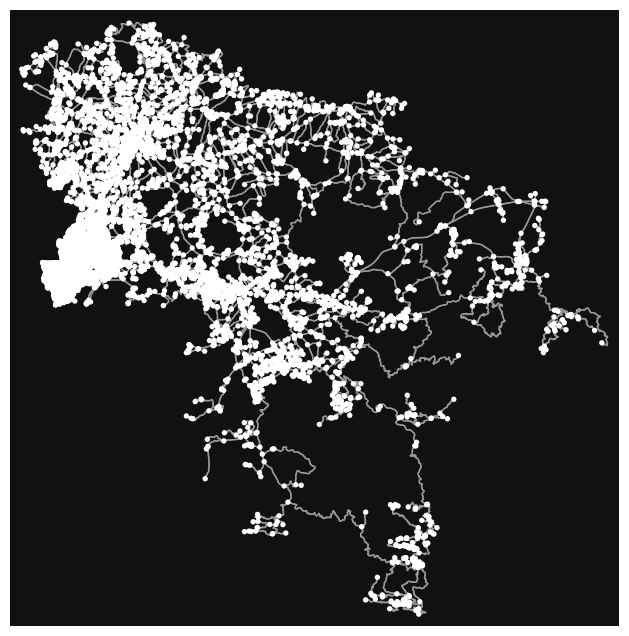

In [39]:
G = ox.graph_from_place("Battalgazi Malatya, Turkey", network_type="drive")
fig, ax = ox.plot_graph(G)

In [40]:
# convert your MultiDiGraph to an undirected MultiGraph
M = ox.utils_graph.get_undirected(G)

# convert your MultiDiGraph to a DiGraph without parallel edges
D = ox.utils_graph.get_digraph(G)

In [41]:
# you can convert your graph to node and edge GeoPandas GeoDataFrames
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)
gdf_nodes.head()

,y,x,street_count,highway,geometry
osmid,,,,,
125640479,38.350491,38.348394,3,NaN,POINT (38.34839 38.35049)
311575872,38.331673,38.486074,3,NaN,POINT (38.48607 38.33167)
311578188,38.349300,38.320318,3,NaN,POINT (38.32032 38.34930)
311578189,38.350947,38.320437,3,NaN,POINT (38.32044 38.35095)
311578193,38.341745,38.311136,3,NaN,POINT (38.31114 38.34175)


In [42]:
gdf_edges.head()

osmid  oneway     highway    junction reversed  \
u         v          key                                                       
125640479 3486465898 0    341455522    True       trunk  roundabout    False   
          5416513414 0    561783948    True   secondary         NaN    False   
311575872 2261262405 0    270525085   False   secondary         NaN    False   
          7179924601 0    769154191    True  trunk_link         NaN    False   
311578188 7084313339 0     28369236   False    tertiary         NaN    False   

                           length  \
u         v          key            
125640479 3486465898 0     23.880   
          5416513414 0    100.879   
311575872 2261262405 0      9.394   
          7179924601 0     30.261   
311578188 7084313339 0     36.509   

                                                                   geometry  \
u         v          key                                                      
125640479 3486465898 0    LINESTRING (38.34839 38.35049, 38.34844 38.350...   
          5416513414 0    LINESTRING (38.34839 38.35049, 38.34828 38.350...   
311575872 2261262405 0    LINESTRING (38.48607 38.33167, 38.48605 38.33159)   
          7179924601 0    LINESTRING (38.48607 38.33167, 38.48618 38.33193)   
311578188 7084313339 0    LINESTRING (38.32032 38.34930, 38.32034 38.349...   

                            ref name bridge lanes maxspeed tunnel  
u         v          key                                           
125640479 3486465898 0      NaN  NaN    NaN   NaN      NaN    NaN  
          5416513414 0      NaN  NaN    NaN   NaN      NaN    NaN  
311575872 2261262405 0    44-25  NaN    NaN   NaN      NaN    NaN  
          7179924601 0      NaN  NaN    NaN   NaN      NaN    NaN  
311578188 7084313339 0      NaN  NaN    NaN   NaN      NaN    NaN

In [43]:
# convert node/edge GeoPandas GeoDataFrames to a NetworkX MultiDiGraph
G2 = ox.graph_from_gdfs(gdf_nodes, gdf_edges, graph_attrs=G.graph)

In [44]:
# what sized area does our network cover in square meters?
G_proj = ox.project_graph(G)
nodes_proj = ox.graph_to_gdfs(G_proj, edges=False)
graph_area_m = nodes_proj.unary_union.convex_hull.area
graph_area_m

941199627.7629799

In [45]:
# show some basic stats about the network
ox.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)

{'n': 8121,
 'm': 20813,
 'k_avg': 5.125723433074745,
 'edge_length_total': 4234807.067999983,
 'edge_length_avg': 203.4693253255169,
 'streets_per_node_avg': 2.7060706809506216,
 'streets_per_node_counts': {0: 0, 1: 1640, 2: 5, 3: 5601, 4: 852, 5: 23},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.2019455732052703,
  2: 0.0006156877231867997,
  3: 0.689693387513853,
  4: 0.10491318803103065,
  5: 0.002832163526659278},
 'intersection_count': 6481,
 'street_length_total': 2200813.5259999936,
 'street_segment_count': 10917,
 'street_length_avg': 201.59508344783308,
 'circuity_avg': 1.129086880198235,
 'self_loop_proportion': 0.0008244023083264633,
 'clean_intersection_count': 5222,
 'node_density_km': 8.628350203773236,
 'intersection_density_km': 6.885893076056439,
 'edge_density_km': 4499.371804964659,
 'street_density_km': 2338.3068385086735,
 'clean_intersection_density_km': 5.548238488376287}

In [46]:
# save graph to disk as geopackage (for GIS) or graphml file (for gephi etc)
ox.save_graph_geopackage(G, filepath="./data/mynetwork.gpkg")
ox.save_graphml(G, filepath="./data/mynetwork.graphml")

In [47]:
# convert graph to line graph so edges become nodes and vice versa
edge_centrality = nx.closeness_centrality(nx.line_graph(G))
nx.set_edge_attributes(G, edge_centrality, "edge_centrality")

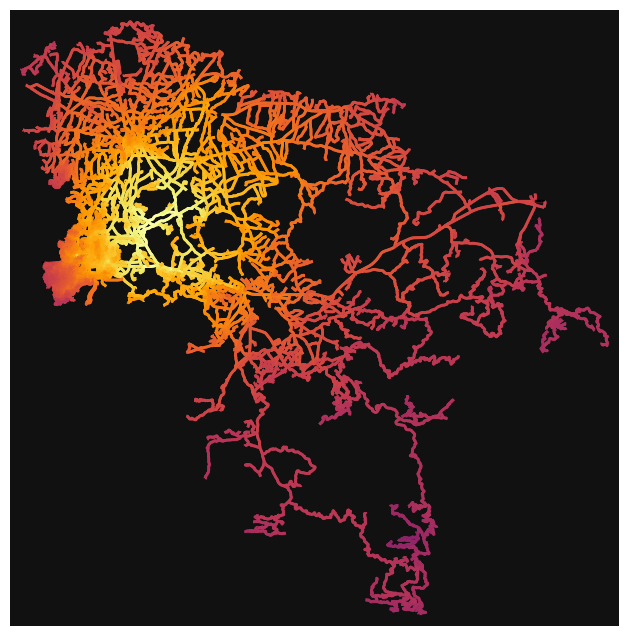

In [48]:
# color edges in original graph with closeness centralities from line graph
ec = ox.plot.get_edge_colors_by_attr(G, "edge_centrality", cmap="inferno")
fig, ax = ox.plot_graph(G, edge_color=ec, edge_linewidth=2, node_size=0)

In [49]:
# impute missing edge speeds and calculate edge travel times with the speed module
G = ox.speed.add_edge_speeds(G)
G = ox.speed.add_edge_travel_times(G)

In [26]:

# get the nearest network nodes to two lat/lng points with the distance module
orig = ox.distance.nearest_nodes(G, X=-122.245846, Y=37.828903)
dest = ox.distance.nearest_nodes(G, X=-122.215006, Y=37.812303)

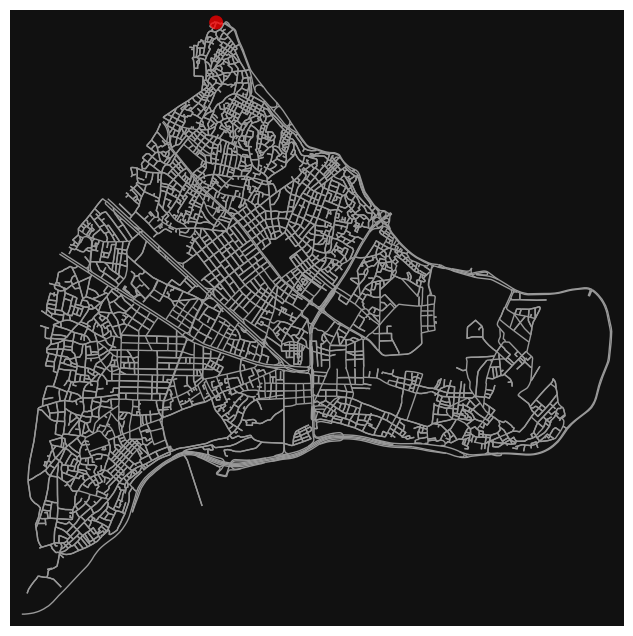

In [27]:
# find the shortest path between nodes, minimizing travel time, then plot it
route = ox.shortest_path(G, orig, dest, weight="travel_time")
fig, ax = ox.plot_graph_route(G, route, node_size=0)


In [28]:
# how long is our route in meters?
edge_lengths = ox.utils_graph.route_to_gdf(G, route)["length"]
round(sum(edge_lengths))

ValueError: Graph contains no edges